<a href="https://colab.research.google.com/github/alyPoint/CEFET---Processamento-de-Sinais-I-140826/blob/main/Pratica_4/DSP_1_PRATICA_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Exercício 1**

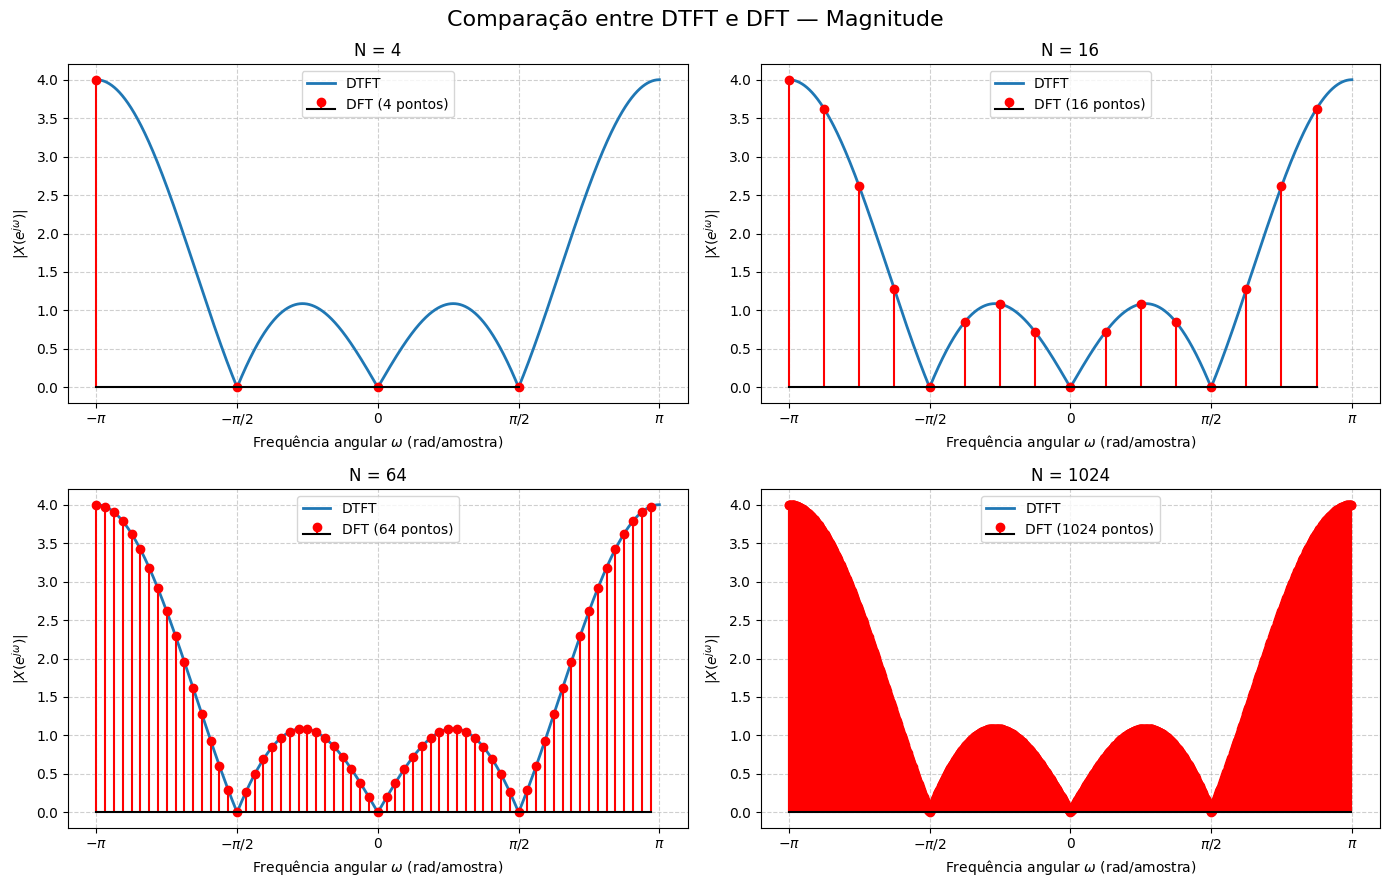

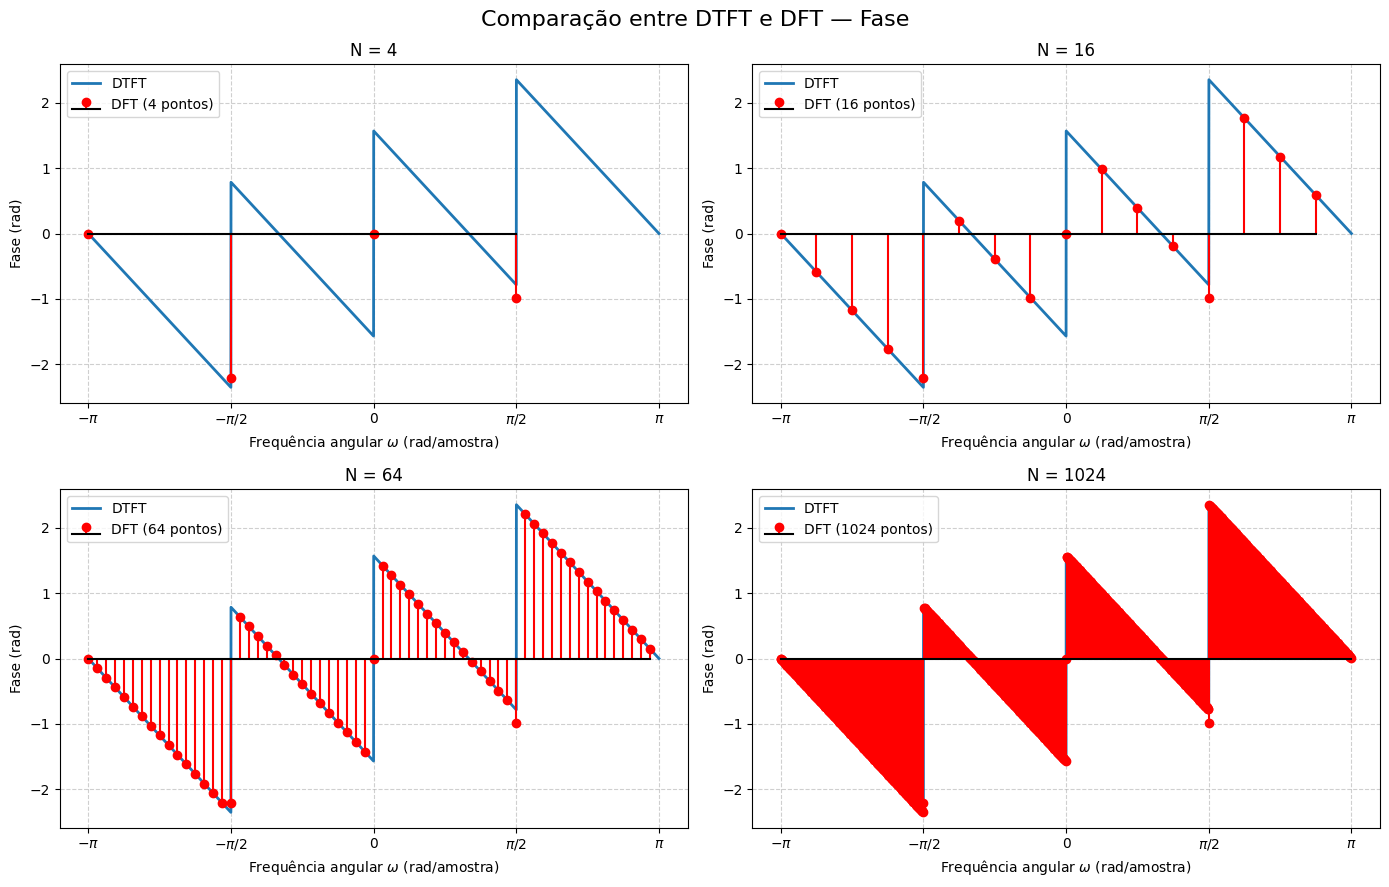

COMPARAÇÃO ENTRE DTFT E DFT

N = 4
Espaçamento entre bins: 1.570796 rad/amostra
Erro máximo:            1.469576e-15
Erro médio:             5.963512e-16

N = 16
Espaçamento entre bins: 0.392699 rad/amostra
Erro máximo:            4.440892e-15
Erro médio:             1.324956e-15

N = 64
Espaçamento entre bins: 0.098175 rad/amostra
Erro máximo:            4.440892e-15
Erro médio:             1.262932e-15

N = 1024
Espaçamento entre bins: 0.006136 rad/amostra
Erro máximo:            4.890025e-15
Erro médio:             1.222950e-15


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. DEFINIÇÃO DO SINAL
# ============================================================

# x[n] = δ[n] - δ[n-1] + δ[n-2] - δ[n-3]

x = np.array([1, -1, 1, -1])

# Índices temporais do sinal
n = np.arange(len(x))


# ============================================================
# 2. CÁLCULO DA DTFT MANUALMENTE
# ============================================================

# Eixo de frequência contínuo
# Usamos muitos pontos apenas para representar graficamente
# a DTFT de forma suficientemente suave.
w = np.linspace(-np.pi, np.pi, 5000)

# Vetor para armazenar a DTFT
X_dtft = np.zeros(len(w), dtype=complex)

# Cálculo direto pela definição:
#
# X(e^jw) = Σ x[n] e^(-jωn)
#
for i, freq in enumerate(w):
    X_dtft[i] = np.sum(x * np.exp(-1j * freq * n))


# ============================================================
# 3. FUNÇÃO PARA CALCULAR A DFT MANUALMENTE
# ============================================================

def calcular_dft(x, N):
    """
    Calcula a DFT de N pontos utilizando diretamente
    a definição da DFT, sem utilizar FFT.

    X[k] = Σ x[n] e^(-j 2πkn/N)
    """

    # --------------------------------------------------------
    # Zero-padding
    # --------------------------------------------------------

    # Criamos um vetor de N pontos.
    # Os primeiros pontos são o sinal original e os demais
    # são preenchidos com zeros.
    x_N = np.zeros(N)

    x_N[:len(x)] = x

    # Índices temporais
    n_N = np.arange(N)

    # Índices de frequência
    k = np.arange(N)

    # --------------------------------------------------------
    # Matriz da DFT
    # --------------------------------------------------------

    # Produto n*k
    nk = n_N.reshape((N, 1)) * k.reshape((1, N))

    # Matriz:
    #
    # W[n,k] = e^(-j 2πnk/N)
    #
    W = np.exp(-1j * 2 * np.pi * nk / N)

    # --------------------------------------------------------
    # Cálculo da DFT
    # --------------------------------------------------------

    X_dft = np.dot(x_N, W)

    # Frequências correspondentes aos bins da DFT
    w_dft = 2 * np.pi * k / N

    # --------------------------------------------------------
    # Transformação para o intervalo [-π, π]
    # --------------------------------------------------------

    w_dft = (w_dft + np.pi) % (2 * np.pi) - np.pi

    # Ordenar as frequências
    idx = np.argsort(w_dft)

    w_dft = w_dft[idx]
    X_dft = X_dft[idx]

    return w_dft, X_dft


# ============================================================
# 4. VALORES DE N A SEREM COMPARADOS
# ============================================================

N_values = [4, 16, 64, 1024]


# ============================================================
# 5. GRÁFICOS DE MAGNITUDE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes = axes.flatten()

for ax, N in zip(axes, N_values):

    # Calcula a DFT para o N atual
    w_dft, X_dft = calcular_dft(x, N)

    # DTFT
    ax.plot(
        w,
        np.abs(X_dtft),
        label='DTFT',
        linewidth=2
    )

    # DFT
    ax.stem(
        w_dft,
        np.abs(X_dft),
        linefmt='r-',
        markerfmt='ro',
        basefmt='k-',
        label=f'DFT ({N} pontos)'
    )

    ax.set_title(f'N = {N}')

    ax.set_xlabel(r'Frequência angular $\omega$ (rad/amostra)')
    ax.set_ylabel(r'$|X(e^{j\omega})|$')

    ax.set_xticks([
        -np.pi,
        -np.pi/2,
        0,
        np.pi/2,
        np.pi
    ])

    ax.set_xticklabels([
        r'$-\pi$',
        r'$-\pi/2$',
        '0',
        r'$\pi/2$',
        r'$\pi$'
    ])

    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

plt.suptitle(
    'Comparação entre DTFT e DFT — Magnitude',
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# 6. GRÁFICOS DE FASE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes = axes.flatten()

for ax, N in zip(axes, N_values):

    # Calcula a DFT
    w_dft, X_dft = calcular_dft(x, N)

    # DTFT
    ax.plot(
        w,
        np.angle(X_dtft),
        label='DTFT',
        linewidth=2
    )

    # DFT
    ax.stem(
        w_dft,
        np.angle(X_dft),
        linefmt='r-',
        markerfmt='ro',
        basefmt='k-',
        label=f'DFT ({N} pontos)'
    )

    ax.set_title(f'N = {N}')

    ax.set_xlabel(r'Frequência angular $\omega$ (rad/amostra)')
    ax.set_ylabel('Fase (rad)')

    ax.set_xticks([
        -np.pi,
        -np.pi/2,
        0,
        np.pi/2,
        np.pi
    ])

    ax.set_xticklabels([
        r'$-\pi$',
        r'$-\pi/2$',
        '0',
        r'$\pi/2$',
        r'$\pi$'
    ])

    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

plt.suptitle(
    'Comparação entre DTFT e DFT — Fase',
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# 7. COMPARAÇÃO NUMÉRICA
# ============================================================

print("=" * 70)
print("COMPARAÇÃO ENTRE DTFT E DFT")
print("=" * 70)

for N in N_values:

    # Calcula DFT
    w_dft, X_dft = calcular_dft(x, N)

    # Calcula a DTFT exatamente nas frequências da DFT
    X_dtft_nos_bins = np.zeros(N, dtype=complex)

    for i, freq in enumerate(w_dft):
        X_dtft_nos_bins[i] = np.sum(
            x * np.exp(-1j * freq * n)
        )

    # Erro absoluto entre DFT e DTFT
    erro = np.abs(X_dft - X_dtft_nos_bins)

    # Erro máximo
    erro_max = np.max(erro)

    # Erro médio
    erro_medio = np.mean(erro)

    print(f"\nN = {N}")
    print(f"Espaçamento entre bins: {2*np.pi/N:.6f} rad/amostra")
    print(f"Erro máximo:            {erro_max:.6e}")
    print(f"Erro médio:             {erro_medio:.6e}")

## **Exercício 2**

RESOLUÇÃO DOS CASOS
Frequência de amostragem: fs = 10.0 Hz
Frequências do sinal: 1.0 Hz e 1.1 Hz
Separação entre as frequências: Δf_sinal = 0.1 Hz

DFT 64
  Amostras reais:       64
  Tamanho da DFT:       64
  Janela de observação: 6.40 s
  Espaçamento dos bins: 0.15625 Hz

DFT 128 (64 reais + zeros)
  Amostras reais:       64
  Tamanho da DFT:       128
  Janela de observação: 6.40 s
  Espaçamento dos bins: 0.07812 Hz

DFT 128
  Amostras reais:       128
  Tamanho da DFT:       128
  Janela de observação: 12.80 s
  Espaçamento dos bins: 0.07812 Hz

DFT 256 (128 reais + zeros)
  Amostras reais:       128
  Tamanho da DFT:       256
  Janela de observação: 12.80 s
  Espaçamento dos bins: 0.03906 Hz

DFT 512 (128 reais + zeros)
  Amostras reais:       128
  Tamanho da DFT:       512
  Janela de observação: 12.80 s
  Espaçamento dos bins: 0.01953 Hz



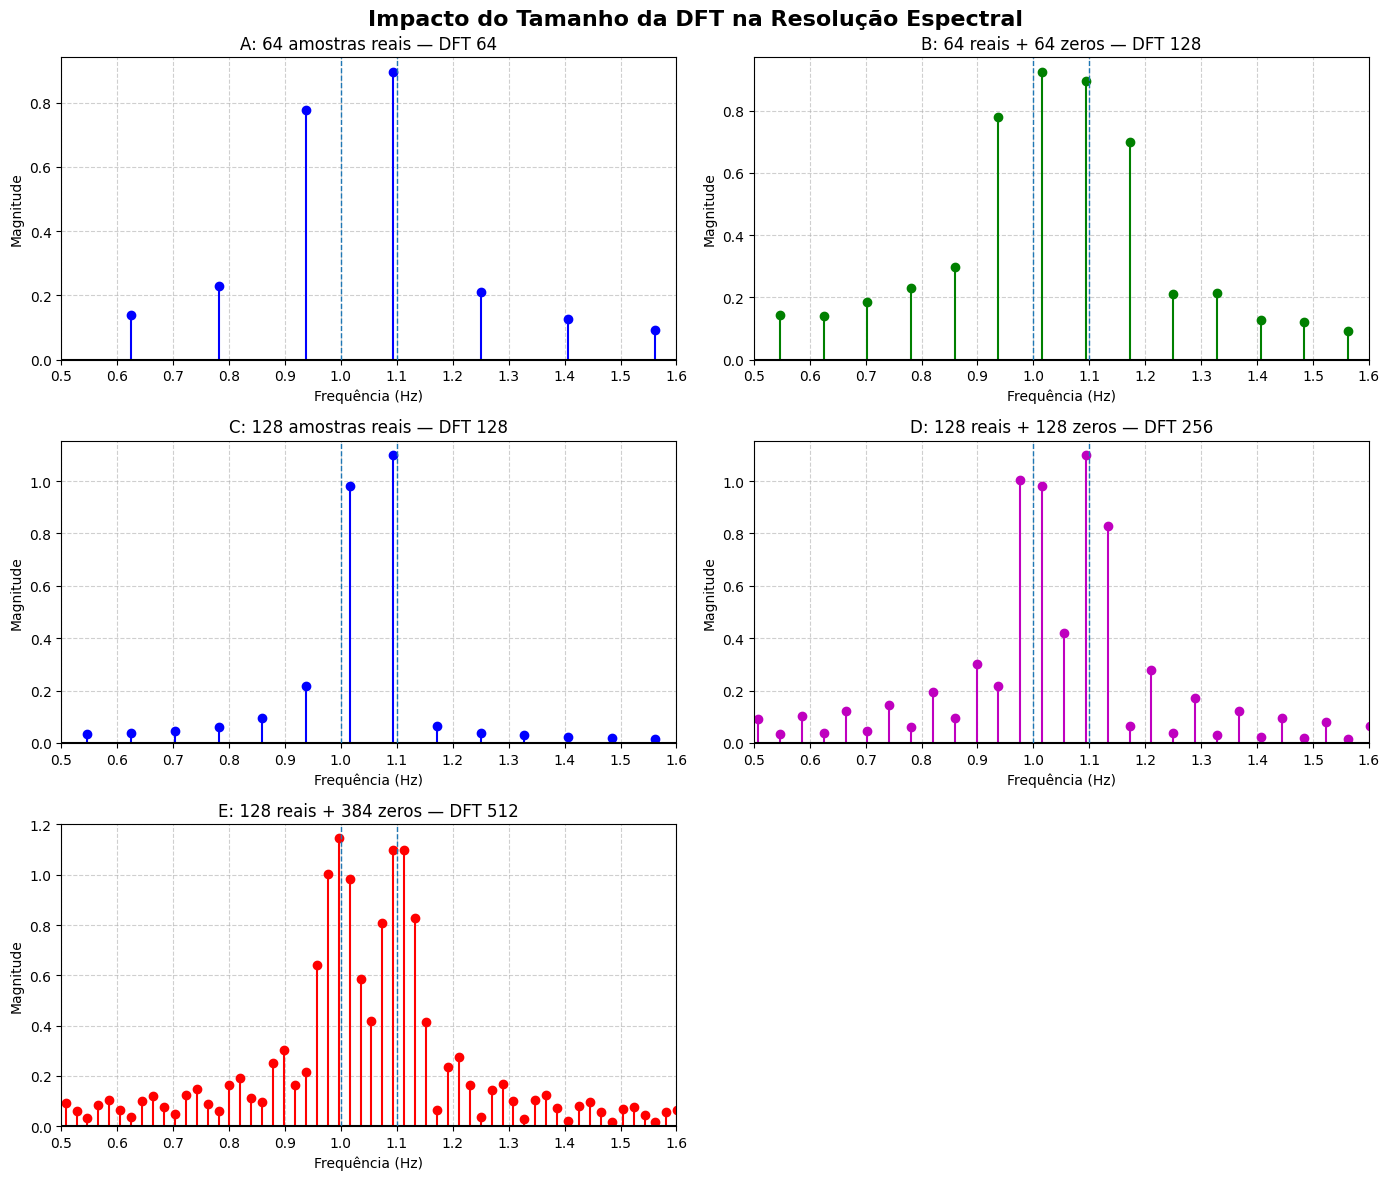

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. CONFIGURAÇÕES
# ============================================================

fs = 10.0          # Frequência de amostragem [Hz]

f1 = 1.0           # Primeira frequência [Hz]
f2 = 1.1           # Segunda frequência [Hz]

# ============================================================
# 2. FUNÇÃO PARA CALCULAR A DFT MANUALMENTE
# ============================================================

def dft_manual(x, N_dft, fs):
    """
    Calcula a DFT manualmente, sem utilizar FFT.

    x     -> sinal no tempo
    N_dft -> tamanho da DFT
    fs    -> frequência de amostragem
    """

    N_x = len(x)

    # --------------------------------------------------------
    # Zero-padding
    # --------------------------------------------------------

    if N_dft >= N_x:
        x_pad = np.concatenate(
            [x, np.zeros(N_dft - N_x)]
        )
    else:
        # Caso N_dft seja menor que o número de amostras,
        # utiliza apenas as primeiras N_dft amostras.
        x_pad = x[:N_dft]

    # --------------------------------------------------------
    # Índices
    # --------------------------------------------------------

    n = np.arange(N_dft)
    k = np.arange(N_dft)

    # --------------------------------------------------------
    # Matriz da DFT
    # --------------------------------------------------------

    nk = n.reshape((N_dft, 1)) * k.reshape((1, N_dft))

    W = np.exp(
        -1j * 2 * np.pi * nk / N_dft
    )

    # --------------------------------------------------------
    # DFT
    # --------------------------------------------------------

    X = np.dot(x_pad, W)

    # Frequências dos bins
    freqs = k * fs / N_dft

    # --------------------------------------------------------
    # Espectro unilateral
    # --------------------------------------------------------

    # Apenas frequências entre 0 e fs/2
    limite = N_dft // 2 + 1

    freqs = freqs[:limite]
    X = X[:limite]

    # Magnitude normalizada
    magnitude = np.abs(X) / N_x

    # Correção para espectro unilateral:
    # as componentes que não estão em DC ou Nyquist
    # devem ser multiplicadas por 2.
    magnitude[1:-1] *= 2

    return freqs, magnitude


# ============================================================
# 3. GERAÇÃO DO SINAL
# ============================================================

# ------------------------------------------------------------
# Caso 1: 64 amostras reais
# ------------------------------------------------------------

N_real_64 = 64

t64 = np.arange(N_real_64) / fs

x64 = (
    np.sin(2 * np.pi * f1 * t64)
    +
    np.sin(2 * np.pi * f2 * t64)
)


# ------------------------------------------------------------
# Caso 2: 128 amostras reais
# ------------------------------------------------------------

N_real_128 = 128

t128 = np.arange(N_real_128) / fs

x128 = (
    np.sin(2 * np.pi * f1 * t128)
    +
    np.sin(2 * np.pi * f2 * t128)
)


# ============================================================
# 4. CÁLCULO DOS CASOS
# ============================================================

# ------------------------------------------------------------
# Janela de 64 amostras
# ------------------------------------------------------------

f_64, X_64 = dft_manual(
    x64,
    64,
    fs
)

# 64 amostras reais + 64 zeros
f_128_zp64, X_128_zp64 = dft_manual(
    x64,
    128,
    fs
)


# ------------------------------------------------------------
# Janela de 128 amostras
# ------------------------------------------------------------

f_128, X_128 = dft_manual(
    x128,
    128,
    fs
)

# 128 amostras reais + 128 zeros
f_256_zp, X_256_zp = dft_manual(
    x128,
    256,
    fs
)

# 128 amostras reais + 384 zeros
f_512_zp, X_512_zp = dft_manual(
    x128,
    512,
    fs
)


# ============================================================
# 5. INFORMAÇÕES SOBRE A RESOLUÇÃO
# ============================================================

print("=" * 65)
print("RESOLUÇÃO DOS CASOS")
print("=" * 65)

print(f"Frequência de amostragem: fs = {fs} Hz")
print(f"Frequências do sinal: {f1} Hz e {f2} Hz")
print(f"Separação entre as frequências: Δf_sinal = {f2-f1:.1f} Hz")

print()

casos = [
    ("DFT 64", 64, 64),
    ("DFT 128 (64 reais + zeros)", 128, 64),
    ("DFT 128", 128, 128),
    ("DFT 256 (128 reais + zeros)", 256, 128),
    ("DFT 512 (128 reais + zeros)", 512, 128)
]

for nome, N_dft, N_real in casos:

    delta_f = fs / N_dft
    janela = N_real / fs

    print(f"{nome}")
    print(f"  Amostras reais:       {N_real}")
    print(f"  Tamanho da DFT:       {N_dft}")
    print(f"  Janela de observação: {janela:.2f} s")
    print(f"  Espaçamento dos bins: {delta_f:.5f} Hz")
    print()


# ============================================================
# 6. GRÁFICOS
# ============================================================

fig, axs = plt.subplots(
    3,
    2,
    figsize=(14, 12)
)

fig.suptitle(
    'Impacto do Tamanho da DFT na Resolução Espectral',
    fontsize=16,
    fontweight='bold'
)


# ============================================================
# A — 64 amostras reais, DFT 64
# ============================================================

axs[0, 0].stem(
    f_64,
    X_64,
    linefmt='b-',
    markerfmt='bo',
    basefmt='k-'
)

axs[0, 0].set_title(
    'A: 64 amostras reais — DFT 64'
)

axs[0, 0].axvline(
    f1,
    linestyle='--',
    linewidth=1
)

axs[0, 0].axvline(
    f2,
    linestyle='--',
    linewidth=1
)


# ============================================================
# B — 64 reais + 64 zeros
# ============================================================

axs[0, 1].stem(
    f_128_zp64,
    X_128_zp64,
    linefmt='g-',
    markerfmt='go',
    basefmt='k-'
)

axs[0, 1].set_title(
    'B: 64 reais + 64 zeros — DFT 128'
)

axs[0, 1].axvline(
    f1,
    linestyle='--',
    linewidth=1
)

axs[0, 1].axvline(
    f2,
    linestyle='--',
    linewidth=1
)


# ============================================================
# C — 128 amostras reais, DFT 128
# ============================================================

axs[1, 0].stem(
    f_128,
    X_128,
    linefmt='b-',
    markerfmt='bo',
    basefmt='k-'
)

axs[1, 0].set_title(
    'C: 128 amostras reais — DFT 128'
)

axs[1, 0].axvline(
    f1,
    linestyle='--',
    linewidth=1
)

axs[1, 0].axvline(
    f2,
    linestyle='--',
    linewidth=1
)


# ============================================================
# D — 128 reais + 128 zeros
# ============================================================

axs[1, 1].stem(
    f_256_zp,
    X_256_zp,
    linefmt='m-',
    markerfmt='mo',
    basefmt='k-'
)

axs[1, 1].set_title(
    'D: 128 reais + 128 zeros — DFT 256'
)

axs[1, 1].axvline(
    f1,
    linestyle='--',
    linewidth=1
)

axs[1, 1].axvline(
    f2,
    linestyle='--',
    linewidth=1
)


# ============================================================
# E — 128 reais + 384 zeros
# ============================================================

axs[2, 0].stem(
    f_512_zp,
    X_512_zp,
    linefmt='r-',
    markerfmt='ro',
    basefmt='k-'
)

axs[2, 0].set_title(
    'E: 128 reais + 384 zeros — DFT 512'
)

axs[2, 0].axvline(
    f1,
    linestyle='--',
    linewidth=1
)

axs[2, 0].axvline(
    f2,
    linestyle='--',
    linewidth=1
)


# ============================================================
# 7. CONFIGURAÇÕES DOS GRÁFICOS
# ============================================================

for ax in axs.flat:

    ax.set_xlim(0.5, 1.6)

    ax.set_ylim(bottom=0)

    ax.set_xlabel('Frequência (Hz)')

    ax.set_ylabel('Magnitude')

    ax.grid(
        True,
        linestyle='--',
        alpha=0.6
    )

    ax.set_xticks(
        np.arange(0.5, 1.61, 0.1)
    )


# Remove o último subplot vazio
fig.delaxes(axs[2, 1])

plt.tight_layout()

plt.show()

## **Exercício 3**

Selecione o arquivo 'handel.wav':


Saving handel.wav to handel.wav

Informações do áudio:
Frequência de amostragem: 8192 Hz
Número de amostras: 73113
Duração: 8.92 s

Processando DFT e compressão...
Isso pode levar algum tempo, pois a DFT está sendo
calculada diretamente, sem utilizar FFT.

Processamento concluído!


RESULTADOS DA COMPRESSÃO
   Energia    Coef./bloco       Mantidos     Eliminados     Fat. Compressão               MSE
----------------------------------------------------------------------------------------------------
    99.5%         166.63         65.09%         34.91%               1.54x      2.945603e-04
    99.0%         139.64         54.55%         45.45%               1.83x      5.906237e-04
    90.0%          42.92         16.76%         83.24%               5.97x      5.852659e-03
    75.0%          17.65          6.89%         93.11%              14.51x      1.419952e-02
    50.0%           6.46          2.52%         97.48%              39.62x      2.647759e-02


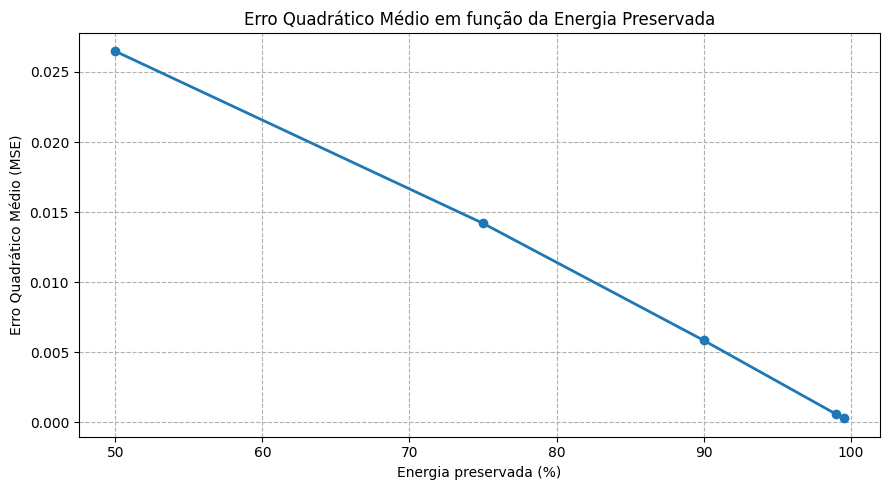

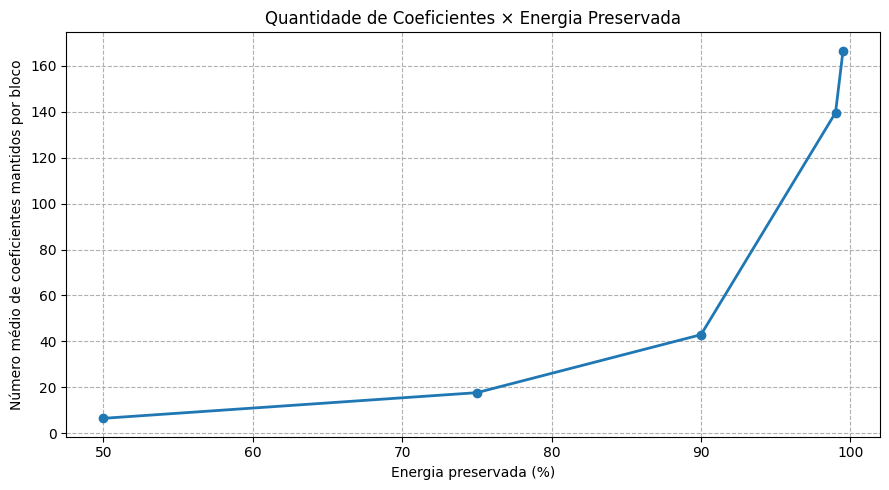

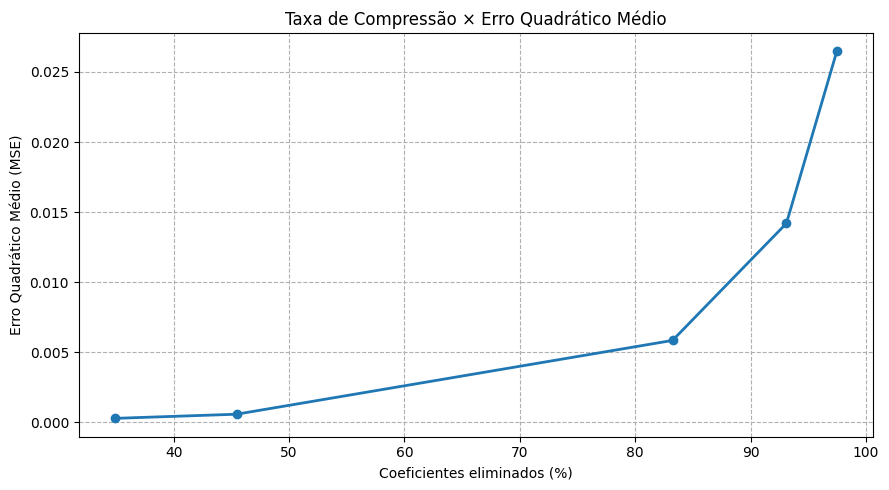



ÁUDIO ORIGINAL



Áudio comprimido — 99.5% da energia preservada



Áudio comprimido — 99.0% da energia preservada



Áudio comprimido — 90.0% da energia preservada



Áudio comprimido — 75.0% da energia preservada



Áudio comprimido — 50.0% da energia preservada



Arquivos de áudio comprimidos salvos no Colab.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from google.colab import files
import IPython.display as ipd

# ============================================================
# 1. UPLOAD DO ÁUDIO
# ============================================================

print("Selecione o arquivo 'handel.wav':")

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Leitura do áudio
signal, fs = sf.read(file_name)

# Converte para float
signal = signal.astype(float)

# Se for estéreo, converte para mono
if signal.ndim > 1:
    signal = np.mean(signal, axis=1)

# Normalização
max_value = np.max(np.abs(signal))

if max_value > 0:
    signal = signal / max_value

print("\nInformações do áudio:")
print(f"Frequência de amostragem: {fs} Hz")
print(f"Número de amostras: {len(signal)}")
print(f"Duração: {len(signal)/fs:.2f} s")


# ============================================================
# 2. PARÂMETROS DA COMPRESSÃO
# ============================================================

# Tamanho dos blocos da DFT
block_size = 256

# Fatores de energia solicitados na questão
energy_ratios = [
    0.995,
    0.990,
    0.900,
    0.750,
    0.500
]


# ============================================================
# 3. MATRIZES DA DFT E IDFT
# ============================================================

# Como todos os blocos possuem 256 pontos, podemos
# calcular a matriz da DFT apenas uma vez.

N = block_size

n = np.arange(N)
k = np.arange(N)

nk = n.reshape((N, 1)) * k.reshape((1, N))

# Matriz da DFT
W = np.exp(
    -1j * 2 * np.pi * nk / N
)

# Matriz da IDFT
W_inv = np.exp(
    1j * 2 * np.pi * nk / N
) / N


# ============================================================
# 4. FUNÇÃO DFT MANUAL
# ============================================================

def dft_manual(block):
    """
    Calcula a DFT diretamente pela definição.
    Não utiliza FFT.
    """
    return np.dot(block, W)


# ============================================================
# 5. FUNÇÃO IDFT MANUAL
# ============================================================

def idft_manual(X):
    """
    Calcula a IDFT diretamente pela definição.
    Não utiliza IFFT.
    """
    return np.real(np.dot(X, W_inv))


# ============================================================
# 6. COMPRESSÃO POR RETENÇÃO DE ENERGIA
# ============================================================

def compress_by_energy(X, energy_ratio):
    """
    Mantém os coeficientes de maior energia até que a
    energia acumulada atinja o percentual especificado.

    energy_ratio:
        0.995 -> 99,5%
        0.990 -> 99,0%
        0.900 -> 90,0%
        etc.
    """

    # Energia de cada coeficiente
    energy = np.abs(X) ** 2

    # Energia total
    total_energy = np.sum(energy)

    # Energia que deve ser preservada
    target_energy = energy_ratio * total_energy

    # Ordena os coeficientes da maior para a menor energia
    sorted_indices = np.argsort(energy)[::-1]

    # Máscara dos coeficientes mantidos
    mask = np.zeros(len(X), dtype=bool)

    accumulated_energy = 0.0
    number_coefficients = 0

    # Seleciona os coeficientes até atingir o
    # percentual de energia desejado
    for idx in sorted_indices:

        accumulated_energy += energy[idx]

        mask[idx] = True
        number_coefficients += 1

        if accumulated_energy >= target_energy:
            break

    # Remove os coeficientes de menor energia
    X_compressed = X * mask

    return X_compressed, number_coefficients


# ============================================================
# 7. PREPARAÇÃO DOS BLOCOS
# ============================================================

# Número de blocos necessários
num_blocks = int(np.ceil(len(signal) / block_size))

# Preenche o último bloco com zeros, se necessário
total_length = num_blocks * block_size

signal_padded = np.pad(
    signal,
    (0, total_length - len(signal)),
    mode='constant'
)


# ============================================================
# 8. PROCESSAMENTO
# ============================================================

reconstructed_signals = {}

# Número total de coeficientes da representação original
total_coefficients = num_blocks * block_size

# Dicionário para guardar estatísticas
results = {}

print("\nProcessando DFT e compressão...")
print("Isso pode levar algum tempo, pois a DFT está sendo")
print("calculada diretamente, sem utilizar FFT.\n")


# ------------------------------------------------------------
# Primeiro calculamos as DFTs dos blocos apenas uma vez.
# ------------------------------------------------------------

X_blocks = []

for b in range(num_blocks):

    start = b * block_size
    end = start + block_size

    block = signal_padded[start:end]

    # DFT manual
    X = dft_manual(block)

    X_blocks.append(X)


# ------------------------------------------------------------
# Agora fazemos cada nível de compressão
# ------------------------------------------------------------

for r in energy_ratios:

    reconstructed = np.zeros(total_length)

    total_kept = 0

    for b in range(num_blocks):

        start = b * block_size
        end = start + block_size

        X = X_blocks[b]

        # Compressão
        X_compressed, n_kept = compress_by_energy(
            X,
            r
        )

        total_kept += n_kept

        # IDFT
        block_reconstructed = idft_manual(
            X_compressed
        )

        reconstructed[start:end] = block_reconstructed


    # Remove o padding utilizado no último bloco
    reconstructed = reconstructed[:len(signal)]

    # Guarda o sinal reconstruído
    reconstructed_signals[r] = reconstructed

    # --------------------------------------------------------
    # Cálculo do erro
    # --------------------------------------------------------

    error = signal - reconstructed

    # Erro quadrático médio
    mse = np.mean(error ** 2)

    # RMSE
    rmse = np.sqrt(mse)

    # --------------------------------------------------------
    # Quantidade média de coeficientes mantidos por bloco
    # --------------------------------------------------------

    average_kept = total_kept / num_blocks

    # Percentual de coeficientes mantidos
    percentage_kept = (
        total_kept / total_coefficients
    ) * 100

    # Percentual de coeficientes eliminados
    compression_percentage = (
        1 - total_kept / total_coefficients
    ) * 100

    # Fator de compressão
    compression_factor = (
        total_coefficients / total_kept
    )

    # Guarda resultados
    results[r] = {
        'total_kept': total_kept,
        'average_kept': average_kept,
        'percentage_kept': percentage_kept,
        'compression_percentage': compression_percentage,
        'compression_factor': compression_factor,
        'mse': mse,
        'rmse': rmse
    }


print("Processamento concluído!")


# ============================================================
# 9. TABELA DE RESULTADOS
# ============================================================

print("\n")
print("=" * 100)
print("RESULTADOS DA COMPRESSÃO")
print("=" * 100)

print(
    f"{'Energia':>10}"
    f"{'Coef./bloco':>15}"
    f"{'Mantidos':>15}"
    f"{'Eliminados':>15}"
    f"{'Fat. Compressão':>20}"
    f"{'MSE':>18}"
)

print("-" * 100)

for r in energy_ratios:

    result = results[r]

    print(
        f"{r*100:>8.1f}%"
        f"{result['average_kept']:>15.2f}"
        f"{result['percentage_kept']:>14.2f}%"
        f"{result['compression_percentage']:>14.2f}%"
        f"{result['compression_factor']:>19.2f}x"
        f"{result['mse']:>18.6e}"
    )


# ============================================================
# 10. GRÁFICO — MSE × ENERGIA RETIDA
# ============================================================

r_percent = np.array(energy_ratios) * 100

mse_values = np.array([
    results[r]['mse']
    for r in energy_ratios
])

plt.figure(figsize=(9, 5))

plt.plot(
    r_percent,
    mse_values,
    'o-',
    linewidth=2
)

plt.xlabel('Energia preservada (%)')
plt.ylabel('Erro Quadrático Médio (MSE)')

plt.title(
    'Erro Quadrático Médio em função da Energia Preservada'
)

plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()


# ============================================================
# 11. GRÁFICO — COEFICIENTES MANTIDOS
# ============================================================

average_coefficients = np.array([
    results[r]['average_kept']
    for r in energy_ratios
])

plt.figure(figsize=(9, 5))

plt.plot(
    r_percent,
    average_coefficients,
    'o-',
    linewidth=2
)

plt.xlabel('Energia preservada (%)')
plt.ylabel('Número médio de coeficientes mantidos por bloco')

plt.title(
    'Quantidade de Coeficientes × Energia Preservada'
)

plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()


# ============================================================
# 12. GRÁFICO — TAXA DE COMPRESSÃO × MSE
# ============================================================

compression_percentage = np.array([
    results[r]['compression_percentage']
    for r in energy_ratios
])

plt.figure(figsize=(9, 5))

plt.plot(
    compression_percentage,
    mse_values,
    'o-',
    linewidth=2
)

plt.xlabel('Coeficientes eliminados (%)')
plt.ylabel('Erro Quadrático Médio (MSE)')

plt.title(
    'Taxa de Compressão × Erro Quadrático Médio'
)

plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()


# ============================================================
# 13. REPRODUÇÃO DO ÁUDIO ORIGINAL
# ============================================================

print("\n")
print("=" * 70)
print("ÁUDIO ORIGINAL")
print("=" * 70)

ipd.display(
    ipd.Audio(
        signal,
        rate=fs
    )
)


# ============================================================
# 14. REPRODUÇÃO DOS ÁUDIOS COMPRIMIDOS
# ============================================================

for r in energy_ratios:

    print(
        f"\nÁudio comprimido — "
        f"{r*100:.1f}% da energia preservada"
    )

    ipd.display(
        ipd.Audio(
            reconstructed_signals[r],
            rate=fs
        )
    )


# ============================================================
# 15. SALVAR OS ÁUDIOS COMPRIMIDOS
# ============================================================

for r in energy_ratios:

    percentage = int(r * 1000)

    filename = (
        f"handel_comprimido_energia_{percentage/10:.1f}%.wav"
    )

    sf.write(
        filename,
        reconstructed_signals[r],
        fs
    )

print("\nArquivos de áudio comprimidos salvos no Colab.")

In [ ]:
    #os seguintes áudios: original, r = 99.5% e r = 99%, não possuem diferenças notáveis.
    #a partir do r = 99% para baixo, dá para perceber um som meio digital.